## Linear Dimensionality Reduction

### 5. Principal Component Analysis (PCA)
* **Type:** Unsupervised (ignores class labels).
* **Goal:** Find new axes (Principal Components) that maximize the **variance** of the data.
* **Mechanism:** It computes the Eigenvectors of the covariance matrix. The first PC captures the most variance.

### 6. Linear Discriminant Analysis (LDA)
* **Type:** Supervised (uses class labels).
* **Goal:** Find new axes that maximize the **separation** between classes while minimizing the spread within classes.
* **Mechanism:** Maximizes the ratio of "Between-Class Variance" to "Within-Class Variance".

#### 1) Importing Necessary Libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

#### 2) Loading Data:

In [2]:
data = load_wine()
X, y = data.data, data.target

In [3]:
# Scaling Data:
X_scaled = StandardScaler().fit_transform(X)

In [4]:
X_scaled.shape

(178, 13)

In [5]:
y.shape

(178,)

#### 3) PCA (Unsupervised):

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

#### 4) LDA (Supervised):

In [7]:
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

#### 5) Visualizig PCA and LDA:

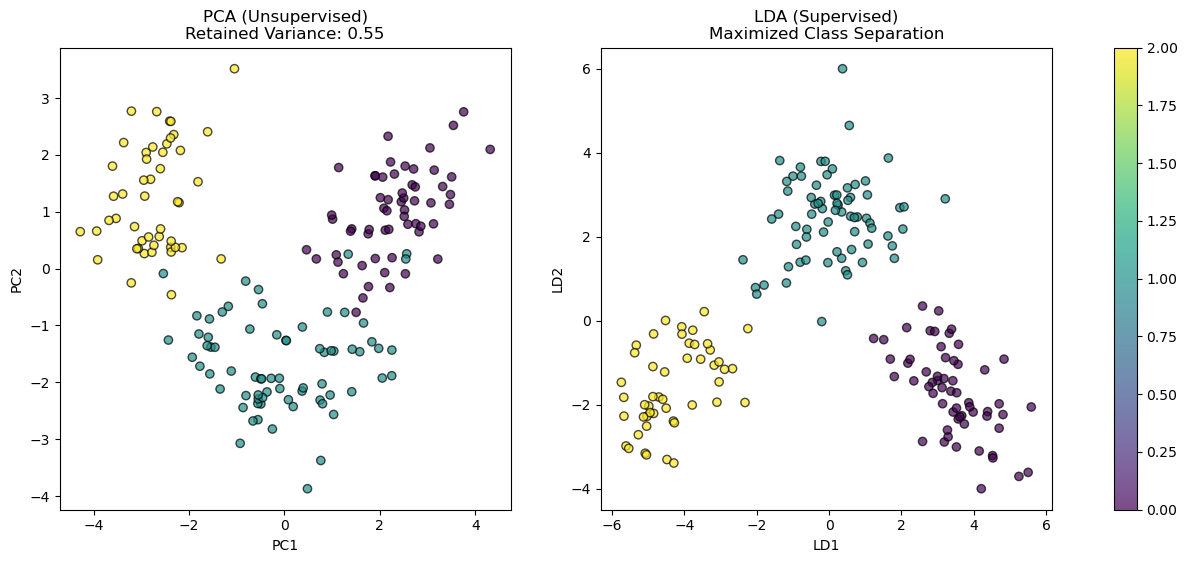

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA:
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k', alpha=0.7)
axes[0].set_title(f"PCA (Unsupervised)\nRetained Variance: {pca.explained_variance_ratio_.sum():.2f}")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# LDA:
scatter = axes[1].scatter(X_lda[:, 0], X_lda[:, 1], c=y, cmap='viridis', edgecolor='k', alpha=0.7)
axes[1].set_title("LDA (Supervised)\nMaximized Class Separation")
axes[1].set_xlabel("LD1")
axes[1].set_ylabel("LD2")

plt.colorbar(scatter, ax=axes.ravel().tolist())
plt.show()

#### 6) Model Comparision (Training on Original Features vs PCA vs LDA):

In [9]:
lr = LogisticRegression()

# Original (13 features)
lr.fit(X_scaled, y)
print(f"Original Accuracy: {lr.score(X_scaled, y):.4f}")

# PCA (2 features)
lr.fit(X_pca, y)
print(f"PCA (2 comp) Accuracy: {lr.score(X_pca, y):.4f}")

# LDA (2 features)
lr.fit(X_lda, y)
print(f"LDA (2 comp) Accuracy: {lr.score(X_lda, y):.4f}")

Original Accuracy: 1.0000
PCA (2 comp) Accuracy: 0.9663
LDA (2 comp) Accuracy: 1.0000
